# Notebook for assigning lava bedding orientations to Michipicoten pmag sites

In [1]:
import geopandas as gpd
import folium
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from geopy.distance import geodesic
from pyhigh import get_elevation
import numpy as np
import pmagpy.ipmag as ipmag
import pystrat
from strat_height import *

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## We need to first make a strat for this formation

- let's set the base to be the Quebec Harbor andesite unit top which is dated by the West Sand Bay tuff at its bottom

- Let's end at the Davieaux unit which is also dated

In [2]:
# West Sand Bay Tuff
WSBT_lon = -85.8871
WSBT_lat = 47.7117

# Davieaux Island Rhyolite
# we develop the strat using the highest data point we care about which is site 15 of Palmer 1987
DIR_lon = 274.2123279 -360
DIR_lat =  47.69565318	

In [3]:
# Let's use the bedding measurements from Annels map
bedding_data = pd.read_csv('../../data/GIS/Michipicoten/MIF_structures.csv')
mean_bedding = ipmag.fisher_mean(bedding_data['dip_dir'].tolist(), bedding_data['dip'].tolist())
mean_bedding_dip_dir = mean_bedding['dec']
mean_bedding_dip = mean_bedding['inc']
print(mean_bedding)

{'dec': 174.65822863954583, 'inc': 19.363561255968257, 'n': 41, 'r': 40.52616872913595, 'k': 84.41823589873697, 'alpha95': 2.4435336076013376, 'csd': 8.815904616287337}


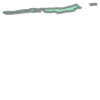

In [4]:
MIF_polygon = gpd.read_file('../../data/GIS/Michipicoten/MIF.shp')
QHA_polygon = MIF_polygon[MIF_polygon['unit name'] == 'Quebec Harbor andesite'].reset_index(drop=True)  
QHA_polygon = QHA_polygon.explode(ignore_index=True)
QHA_polygon['geometry'] = [Polygon([(x[0] % 360, x[1]) for x in poly.exterior.coords]) for poly in QHA_polygon['geometry']]
QHA_polygon = QHA_polygon.unary_union

SSB_polygon = MIF_polygon[MIF_polygon['unit name'] == 'South Shore basalts'].reset_index(drop=True)
SSB_polygon = SSB_polygon.explode(ignore_index=True)
SSB_polygon['geometry'] = [Polygon([(x[0] % 360, x[1]) for x in poly.exterior.coords]) for poly in SSB_polygon['geometry']]
SSB_polygon = SSB_polygon.unary_union
SSB_polygon

## Load pmag data

In [5]:
Fairchild2017_data = pd.read_csv('../../data/pmag_compiled/Fairchild2017/sites.txt',sep='\t',header=1)
Fairchild2017_MIF = Fairchild2017_data[Fairchild2017_data['site'].str.contains('SS')]
Fairchild2017_MIF['bedding_dip_dir'] = mean_bedding_dip_dir
Fairchild2017_MIF['bedding_dip'] = mean_bedding_dip
Fairchild2017_MIF_west = Fairchild2017_MIF[Fairchild2017_MIF['lon'] < -85.727%360].reset_index(drop=True)   
Fairchild2017_MIF_east = Fairchild2017_MIF[Fairchild2017_MIF['lon'] > -85.727%360].reset_index(drop=True)   

Palmer1987_MIF_site_names = ['4', '5', '14', '15', '16', '17']
Palmer1987_results = pd.read_csv('../../data/pmag_compiled/Palmer1987/pmag_results.txt',sep='\t',skiprows=1)
Palmer1987_results['er_citation_names'] = 'Palmer and Davis, 1987'
Palmer1987_MIF = Palmer1987_results[Palmer1987_results['er_site_names'].isin(Palmer1987_MIF_site_names)]
Palmer1987_MIF['bedding_dip_dir'] = mean_bedding_dip_dir
Palmer1987_MIF['bedding_dip'] = mean_bedding_dip
Palmer1987_MIF_west = Palmer1987_MIF[Palmer1987_MIF['average_lon'] < -85.727%360].reset_index(drop=True)
Palmer1987_MIF_east = Palmer1987_MIF[Palmer1987_MIF['average_lon'] > -85.727%360].reset_index(drop=True)

# Fairchild2017_MIF.site

In [6]:
MIF_map = folium.Map(location=[DIR_lat, DIR_lon%360], 
                      zoom_start=12, tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Esri")
plot_lava(MIF_map, QHA_polygon.geoms[1], 'blue')
plot_lava(MIF_map, SSB_polygon.geoms[0], 'green')
plot_lava(MIF_map, SSB_polygon.geoms[1], 'red')

plot_site(MIF_map, Fairchild2017_MIF_west, 'green', popupname='site')
plot_site(MIF_map, Fairchild2017_MIF_east, 'red', popupname='site')
plot_site(MIF_map, Palmer1987_MIF, 'blue', popupname='er_site_names', lat_col='average_lat', lon_col='average_lon')

folium.CircleMarker(location=[DIR_lat, DIR_lon%360], popup='West Sand Bay Tuff', radius=5, color='green', fill=True, fill_color='green', fill_opacity=0.7).add_to(MIF_map)
MIF_map, QHA_relative_height, QHA_height, QHA_distance_from_base = calc_strat(MIF_map, DIR_lat, DIR_lon, mean_bedding_dip_dir+180, mean_bedding_dip, 5000, QHA_polygon.geoms[1], 'green')
MIF_map, SSB_relative_height, SSB_height, SSB_distance_from_base = calc_strat(MIF_map, DIR_lat, DIR_lon, mean_bedding_dip_dir+180, mean_bedding_dip, 5000, SSB_polygon.geoms[0], 'green')

_, top_SSB_relative_height, _, _ = calc_strat(MIF_map, DIR_lat, DIR_lon, mean_bedding_dip_dir+180, mean_bedding_dip, 5000, SSB_polygon.geoms[0], 'green', multipoint_selection='max')
print('relative height', QHA_relative_height, 'height', QHA_height, 'distance from base', QHA_distance_from_base)
print('relative height', SSB_relative_height, 'height', SSB_height, 'distance from base', SSB_distance_from_base)
print('height of the top of SSB', top_SSB_relative_height)
QHA_thickness = QHA_relative_height-SSB_relative_height
SSB_thickness = SSB_relative_height-top_SSB_relative_height
SSB_DIR_cover = top_SSB_relative_height
print('base of South Shore basalts (thickness of Quebec Harbor andesite) is:', QHA_thickness)
print('thickness of South Shore basalts is:', SSB_thickness)
print('cover between South Shore basalts and Davieaux Island rhyolite:', SSB_DIR_cover)

estimate_height_from_strat_top(MIF_map, Fairchild2017_MIF_west, SSB_polygon.geoms[0], QHA_thickness, distance=5000, color='green')
estimate_height_from_strat_top(MIF_map, Fairchild2017_MIF_east, SSB_polygon.geoms[1], QHA_thickness, distance=1000, color='red')
estimate_height_from_strat_top(MIF_map, Palmer1987_MIF_west, QHA_polygon.geoms[1], 0, distance=5000, color='blue', lat_col='average_lat', lon_col='average_lon')
estimate_height_from_strat_top(MIF_map, Palmer1987_MIF_east, SSB_polygon.geoms[1], QHA_thickness, distance=1000, color='blue', lat_col='average_lat', lon_col='average_lon')

MIF_map

site lat 47.69565318 site lon 274.2123279 site elevation 179.0 intersection lat 47.72416614236435 intersection lon 274.2096618648305
site lat 47.69565318 site lon 274.2123279 site elevation 179.0 intersection lat 47.71375885059438 intersection lon 274.21063497332494
site lat 47.69565318 site lon 274.2123279 site elevation 179.0 intersection lat 47.70727268834387 intersection lon 274.21124144614436
relative height 1006.9796000828719 height -1006.9796000828719 distance from base 3176.51118192131
relative height 665.954107069395 height -665.954107069395 distance from base 2017.0768256530928
height of the top of SSB 425.42569677765186
base of South Shore basalts (thickness of Quebec Harbor andesite) is: 341.0254930134769
thickness of South Shore basalts is: 240.52841029174317
cover between South Shore basalts and Davieaux Island rhyolite: 425.42569677765186
site lat 47.705278 site lon 274.270833 site elevation 181.0 intersection lat 47.71566374409492 intersection lon 274.2698619062685
site

## Make MIF strat section

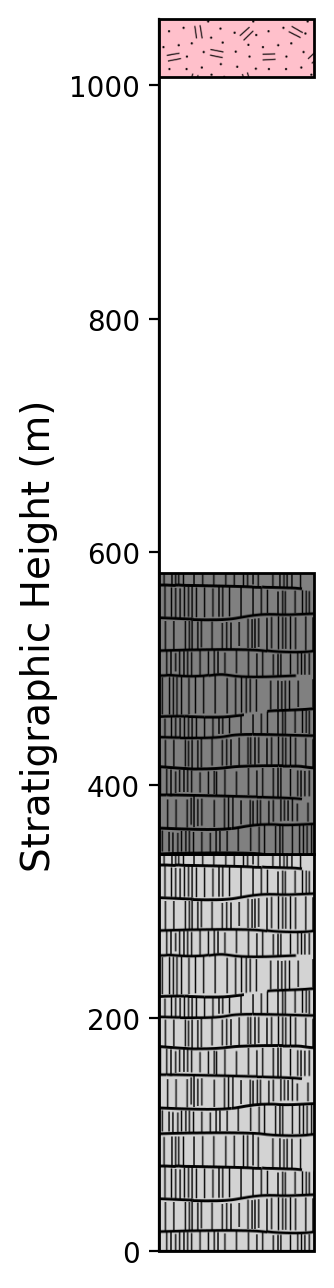

In [7]:
MIF_thickness = [QHA_thickness, SSB_thickness, SSB_DIR_cover, 50] # assume 50m of the rhyolite
MIF_litho = ['andesite', 'basalt', 'cover', 'rhyolite']
MIF_widths = [1, 1, 0, 1]
MIF_colors = ['lightgrey', 'gray', 'white', 'pink']
MIF_swatches = ['717', '717', 0, '727']
MIF_section_df = pd.DataFrame({'thickness': MIF_thickness, 
                            'litho': MIF_litho, 
                            'width': MIF_widths, 
                            'color': MIF_colors,
                            'swatch': MIF_swatches})

MIF_section = pystrat.Section(MIF_section_df['thickness'],           # unit thicknesses
                             MIF_section_df['litho'])
MIF_style = pystrat.Style(MIF_section_df['litho'], MIF_section_df['color'],
                          MIF_section_df['width'], MIF_section_df['swatch'])

plt.figure(figsize=(1, 8))
MIF_section.plot(style=MIF_style, )

# turn off grids
plt.grid(False)
plt.ylabel('Stratigraphic Height (m)', fontsize=14)
plt.xticks([])
# plt.savefig('./code_output/MIF_strat_section.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [8]:
np.sum(MIF_thickness)

1056.979600082872

## Save data

In [9]:
def save_data(file_name, site_data):
    # Write the extra row to the file first
    with open(file_name, 'w') as f:
        f.write('tab\tsite\n')  # Writing the extra row

    # Append the DataFrame to the file with the original headers
    site_data.to_csv(file_name, mode='a', index=False, sep='\t')

In [10]:
Fairchild2017_with_height = pd.concat([Fairchild2017_MIF_west,Fairchild2017_MIF_east]).reset_index(drop=True)
Palmer1987_with_height = pd.concat([Palmer1987_MIF_west,Palmer1987_MIF_east]).reset_index(drop=True)
Palmer1987_MIF_west.height

0      45.760248
1     382.385962
2    1006.979600
3     504.968333
4     711.603561
Name: height, dtype: float64

In [11]:
# save the site data
Fairchild2017_file_name = '../../data/pmag_compiled/Fairchild2017/MIF_sites_with_height.txt'
Palmer1987_file_name = '../../data/pmag_compiled/Palmer1987/MIF_sites_with_height.txt'
save_data(Fairchild2017_file_name, Fairchild2017_with_height)
save_data(Palmer1987_file_name, Palmer1987_with_height)